In [ ]:
#DPEL PROJECT
#FACULTY- PROFESSOR AKANSHA SARAF
#TEAM 24
#SHAURY TANDON ,PRN-25070126162
#SNIGDHA SINGH,PRN-25070126169
#Dataset link https://www.kaggle.com/datasets/muzammilbaloch/spotify-top-tracks-dataset-2000-2019
#topic-spotify top tracks dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

In [ ]:
# 1. INTRODUCTION

# Spotify is one of the world's largest music streaming platforms.
# This project analyses audio features of 2000 songs to understand
# what drives popularity and how listening trends vary across genres.

In [ ]:
# 2. PROBLEM STATEMENT

# Real-World Relevance
# Music streaming platforms rely on audio feature data to build
# recommendation engines and curate personalised playlists.
# By analysing features like danceability, energy, valence, and
# acousticness, we can uncover patterns that distinguish popular
# tracks from less-streamed ones — helping artists, labels, and
# platforms make data-driven decisions.

In [ ]:
# 3. DATASET DESCRIPTION

# 3.1 Load the dataset
url = 'SongDetails.csv'
df = pd.read_csv(url)

# 3.2 Display first 5 rows
df.head()

# 3.3 Dataset size – rows and columns
print(df.shape)

# 3.4 Attributes and data types
df.info()

# 3.5 Statistical summary
df.describe()
#note-
#Attributes / Features:
#duration_ms       : Track length in milliseconds
#explicit          : Whether the track has explicit content (bool)
#year              : Release year of the track
#popularity        : Spotify popularity score (0-100) <- TARGET VARIABLE
#danceability      : How suitable a track is for dancing (0.0-1.0)
#energy            : Perceptual measure of intensity (0.0-1.0)
#key               : Musical key of the track (0-11)
#loudness          : Overall loudness in dB
#mode              : Modality - major (1) or minor (0)
#speechiness       : Presence of spoken words (0.0-1.0)
#acousticness      : Confidence of track being acoustic (0.0-1.0)
#instrumentalness  : Predicts whether a track has no vocals (0.0-1.0)
#liveness          : Detects presence of a live audience (0.0-1.0)
#valence           : Musical positiveness of the track (0.0-1.0)
#tempo             : Estimated tempo in BPM
#Genre columns     : Binary flags - latin, rock, pop, jazz, hip hop

(2000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2000 non-null   int64  
 1   duration_ms        2000 non-null   int64  
 2   explicit           2000 non-null   bool   
 3   year               2000 non-null   int64  
 4   popularity         2000 non-null   int64  
 5   danceability       2000 non-null   float64
 6   energy             2000 non-null   float64
 7   key                2000 non-null   int64  
 8   loudness           2000 non-null   float64
 9   mode               2000 non-null   int64  
 10  speechiness        2000 non-null   float64
 11  acousticness       2000 non-null   float64
 12  instrumentalness   2000 non-null   float64
 13  liveness           2000 non-null   float64
 14  valence            2000 non-null   float64
 15  tempo              2000 non-null   float64
 16  latin        

,Unnamed: 0,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,...,World/Traditional,classical,country,R&B,blues,pop,jazz,hip hop,set(),easy listening
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,228748.124500,2009.49400,59.872500,0.667438,0.720366,5.378000,-5.512434,0.553500,0.103568,...,0.005000,0.000500,0.010500,0.226000,0.002000,0.816500,0.001000,0.389000,0.011000,0.003500
std,577.494589,39136.569008,5.85996,21.335577,0.140416,0.152745,3.615059,1.933482,0.497254,0.096159,...,0.070551,0.022361,0.101956,0.418344,0.044688,0.387173,0.031615,0.487645,0.104329,0.059072
min,0.000000,113000.000000,1998.00000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,499.750000,203580.000000,2004.00000,56.000000,0.581000,0.622000,2.000000,-6.490250,0.000000,0.039600,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,999.500000,223279.500000,2010.00000,65.500000,0.676000,0.736000,6.000000,-5.285000,1.000000,0.059850,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1499.250000,248133.000000,2015.00000,73.000000,0.764000,0.839000,8.000000,-4.167750,1.000000,0.129000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1999.000000,484146.000000,2020.00000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# 4. INITIAL OBSERVATIONS
 # Observations:
# - Dataset has 2000 rows and 31 columns with no missing values or duplicates.
# - 'Unnamed: 0' is just an index column - will be dropped during cleaning.
# - Genre columns are binary flags (0 or 1) already one-hot encoded.
# - 'explicit' is a boolean column that needs to be encoded to int.
# - 'set()' is a malformed column name that needs renaming.
# - Years range from 1998 to 2020.
# 4.1 Check for missing values
print(df.isnull().sum())

# 4.2 Check for duplicate rows
print("Duplicates:", df.duplicated().sum())

# 4.3 Check unique years in the dataset
print("Years:", sorted(df['year'].unique()))

# 4.4 Distribution of explicit vs non-explicit tracks
print(df['explicit'].value_counts())

Unnamed: 0           0
duration_ms          0
explicit             0
year                 0
popularity           0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
latin                0
rock                 0
Dance/Electronic     0
metal                0
Folk/Acoustic        0
World/Traditional    0
classical            0
country              0
R&B                  0
blues                0
pop                  0
jazz                 0
hip hop              0
set()                0
easy listening       0
dtype: int64
Duplicates: 0
Years: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(201

In [ ]:
# 5. HANDLING MISSING VALUES

# 5.1 Confirm no natural missing values exist
print("Missing before injection:", df.isnull().sum().sum())

# 5.2 Artificially introduce missing values to demonstrate handling
np.random.seed(42)
df_demo = df.copy()
for col in ['popularity', 'danceability', 'energy']:
    idx = np.random.choice(df_demo.index, size=20, replace=False)
    df_demo.loc[idx, col] = np.nan

print("Missing after injection:")
print(df_demo[['popularity', 'danceability', 'energy']].isnull().sum())

# 5.3 Display rows where null values were injected
print("Rows with null values:")
print(df_demo[df_demo[['popularity', 'danceability', 'energy']].isnull().any(axis=1)][['popularity', 'danceability', 'energy']])

# 5.4 Fill using SimpleImputer with mean strategy
# Mean is appropriate for these continuous audio features with no extreme value
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df_demo['popularity'] = imputer.fit_transform(df_demo[['popularity']])
df_demo['danceability'] = imputer.fit_transform(df_demo[['danceability']])
df_demo['energy'] = imputer.fit_transform(df_demo[['energy']])

print("Missing after filling:")
print(df_demo[['popularity', 'danceability', 'energy']].isnull().sum())

Missing before injection: 0
Missing after injection:
popularity      20
danceability    20
energy          20
dtype: int64

Rows with null values:
      popularity  danceability  energy
34          58.0         0.633     NaN
56           NaN         0.869   0.887
65           NaN         0.631   0.734
70          55.0           NaN   0.622
109         62.0           NaN   0.929
116         73.0         0.603     NaN
128          NaN         0.446   0.764
130         82.0         0.843     NaN
159         68.0         0.802     NaN
275          NaN         0.665   0.695
297         72.0         0.424     NaN
324         73.0         0.662     NaN
353          NaN         0.646   0.813
374          NaN         0.577   0.749
409         67.0           NaN   0.916
475         55.0         0.663     NaN
584          NaN         0.722   0.329
599         76.0           NaN   0.940
605         73.0           NaN   0.671
746          NaN         0.584   0.699
754         59.0           NaN   0

In [ ]:
# 6. DATA CLEANING

# 6.1 Drop the unnamed index column as it carries no information
df.drop(columns=['Unnamed: 0'], inplace=True)

# 6.2 Rename malformed column 'set()' to 'unknown_genre'
df.rename(columns={'set()': 'unknown_genre'}, inplace=True)

# 6.3 Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

# 6.4 Convert explicit from boolean to int (0/1) for compatibility
df['explicit'] = df['explicit'].astype(int)

# 6.5 Verify corrected data types
print(df[['explicit', 'year', 'popularity']].dtypes)

# 6.6 Verify no out-of-range values in bounded audio features (0.0-1.0)
for col in ['danceability', 'energy', 'valence', 'acousticness']:
    out = df[(df[col] < 0) | (df[col] > 1)]
    print(f"{col} out-of-range values: {len(out)}")

Shape after removing duplicates: (1941, 30)
explicit      int64
year          int64
popularity    int64
dtype: object
danceability out-of-range values: 0
energy out-of-range values: 0
valence out-of-range values: 0
acousticness out-of-range values: 0


In [ ]:
# 7. FEATURE TRANSFORMATION

# 7.1 Convert duration from milliseconds to seconds for readability
df['duration_sec'] = df['duration_ms'] / 1000
print(df[['duration_ms', 'duration_sec']].head())

# 7.2 Extract decade from year to group tracks into time periods
df['decade'] = (df['year'] // 10) * 10
print(df[['year', 'decade']].head())

# 7.3 Create an energy-to-acousticness ratio as a new feature
# High ratio = loud electronic track, low ratio = soft acoustic track
df['energy_acoustic_ratio'] = df['energy'] / (df['acousticness'] + 0.01)
print(df[['energy', 'acousticness', 'energy_acoustic_ratio']].head())

   duration_ms  duration_sec
0       211160       211.160
1       167066       167.066
2       250546       250.546
3       224493       224.493
4       200560       200.560
   year  decade
0  2000    2000
1  1999    1990
2  1999    1990
3  2000    2000
4  2000    2000
   energy  acousticness  energy_acoustic_ratio
0   0.834        0.3000               2.690323
1   0.897        0.0103              44.187192
2   0.496        0.1730               2.710383
3   0.913        0.0263              25.151515
4   0.928        0.0408              18.267717


In [24]:
# 8. ENCODING
# ENCODING JUSTIFICATION
# Label Encoding → 'explicit': Only 2 values (True/False). Binary columns have
#   no ordinality issue, so LE is sufficient and simpler than OHE.
#
# One-Hot Encoding → 'dominant_genre': 12 nominal categories with no natural order.
#   LE would wrongly imply pop > rock > R&B numerically. OHE creates independent
#   binary columns per genre. drop_first=True drops one column to avoid multicollinearity.

# 8.1 Label Encoding - encode 'explicit' and decade column (0 = No, 1 = Yes)
le = LabelEncoder()

print("Before Label Encoding:")
print(df['explicit'].value_counts())

df['explicit'] = le.fit_transform(df['explicit'])

print("After Label Encoding:")
print(df['explicit'].value_counts())
le = LabelEncoder()
df['decade_encoded'] = le.fit_transform(df['decade'])
print(df[['decade', 'decade_encoded']].drop_duplicates().sort_values('decade'))

# 8.2 One-Hot Encoding - derive dominant genre from binary genre flags
# and one-hot encode it as a new set of columns
genre_cols = ['latin', 'rock', 'Dance/Electronic', 'metal', 'Folk/Acoustic',
              'World/Traditional', 'classical', 'country', 'R&B', 'blues',
              'pop', 'jazz', 'hip hop', 'unknown_genre', 'easy listening']

# Assign the genre with value 1 as the dominant genre for each track
df['dominant_genre'] = df[genre_cols].idxmax(axis=1)

# Show dominant_genre before One-Hot Encoding
print("Dominant Genre before One-Hot Encoding:")
print(df['dominant_genre'].value_counts())

# Apply One-Hot Encoding on dominant_genre using get_dummies with drop_first
genre_dummies = pd.get_dummies(df['dominant_genre'], drop_first=True)
df = pd.concat([df, genre_dummies], axis=1)

# Show first 5 rows of the newly added one-hot columns
print("One-Hot Encoded columns (first 5 rows):")
print(genre_dummies.head())

print("One-Hot encoded columns added:", genre_dummies.columns.tolist())

Before Label Encoding:
explicit
0    1404
1     537
Name: count, dtype: int64
After Label Encoding:
explicit
0    1404
1     537
Name: count, dtype: int64
     decade  decade_encoded
1      1990               0
0      2000               1
10     2010               2
308    2020               3
Dominant Genre before One-Hot Encoding:
dominant_genre
pop                  685
R&B                  425
Dance/Electronic     357
rock                 223
hip hop              121
latin                 63
unknown_genre         22
country               19
Folk/Acoustic         13
metal                  9
World/Traditional      3
easy listening         1
Name: count, dtype: int64
One-Hot Encoded columns (first 5 rows):
   Folk/Acoustic    R&B  World/Traditional  country  easy listening  hip hop  \
0          False  False              False    False           False    False   
1          False  False              False    False           False    False   
2          False  False              False  

In [ ]:
# 9. SCALING / NORMALIZATION

# 9.1 Select continuous audio features for scaling
scale_cols = ['duration_ms', 'loudness', 'tempo', 'popularity',
              'danceability', 'energy', 'valence', 'acousticness',
              'speechiness', 'instrumentalness', 'liveness']

# Show original values before any scaling
print("Before Scaling:")
print(df[scale_cols].head())

# 9.2 StandardScaler
# Justified because features like loudness (negative dB) and tempo (50-200 BPM)
# have very different ranges. Standardization brings all to mean=0, std=1.
scaler_std = StandardScaler()
df_std = df.copy()
df_std[scale_cols] = scaler_std.fit_transform(df[scale_cols])

print("After StandardScaler:")
print(df_std[scale_cols].head())
print("Loudness mean before:", round(df['loudness'].mean(), 2), "| after:", round(df_std['loudness'].mean(), 4))
print("Loudness std  before:", round(df['loudness'].std(), 2),  "| after:", round(df_std['loudness'].std(), 4))

# 9.3 MinMaxScaler shown for comparison
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[scale_cols] = scaler_mm.fit_transform(df[scale_cols])

print("After MinMaxScaler:")
print(df_mm[scale_cols].head())
print("Loudness range before:", round(df['loudness'].min(), 2), "to", round(df['loudness'].max(), 2))
print("Loudness range after :", round(df_mm['loudness'].min(), 2), "to", round(df_mm['loudness'].max(), 2))

Before Scaling:
   duration_ms  loudness    tempo  popularity  danceability  energy  valence  \
0       211160    -5.444   95.053          77         0.751   0.834    0.894   
1       167066    -4.918  148.726          79         0.434   0.897    0.684   
2       250546    -9.007  136.859          66         0.529   0.496    0.278   
3       224493    -4.063  119.992          78         0.551   0.913    0.544   
4       200560    -4.806  172.656          65         0.614   0.928    0.879   

   acousticness  speechiness  instrumentalness  liveness  
0        0.3000       0.0437          0.000018    0.3550  
1        0.0103       0.0488          0.000000    0.6120  
2        0.1730       0.0290          0.000000    0.2510  
3        0.0263       0.0466          0.000013    0.3470  
4        0.0408       0.0516          0.001040    0.0845  

After StandardScaler:
   duration_ms  loudness     tempo  popularity  danceability    energy  \
0    -0.444320  0.036154 -0.930399    0.807928      

danceability   -0.000143
energy         -0.013404
valence        -0.011012
dtype: float64


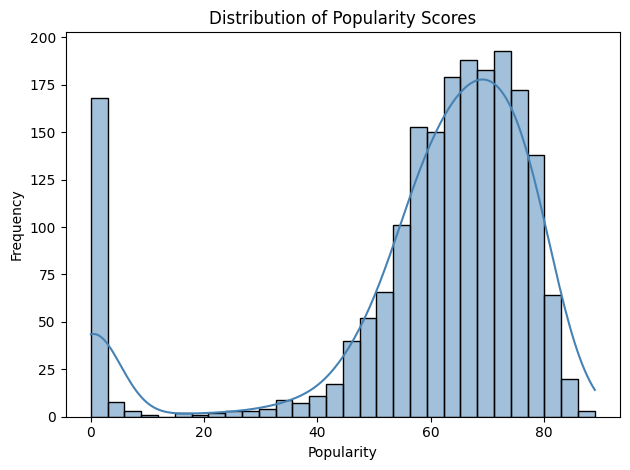

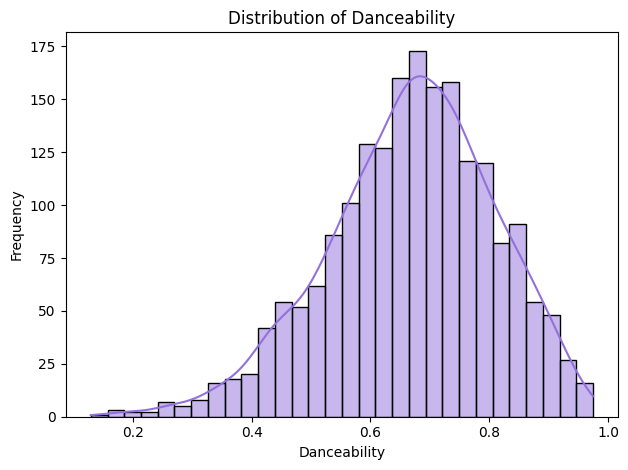

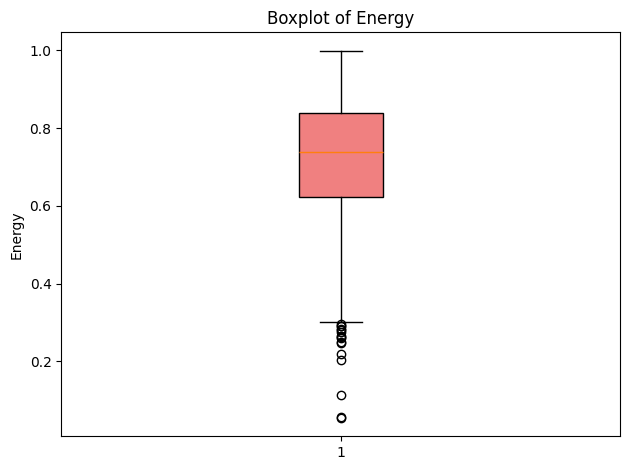

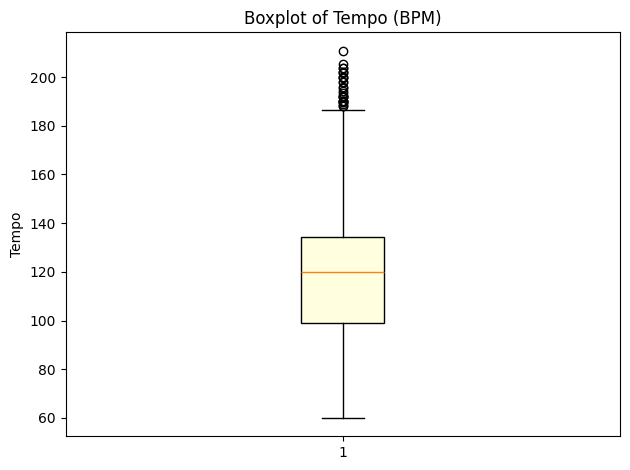

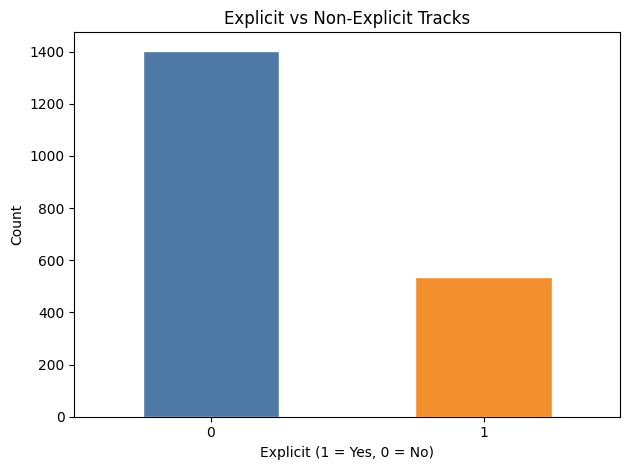

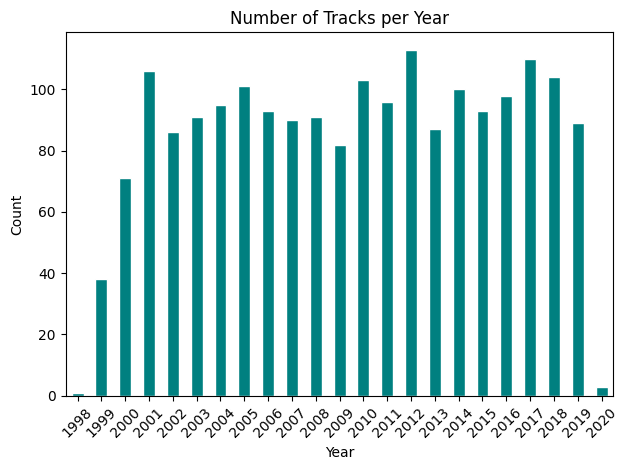

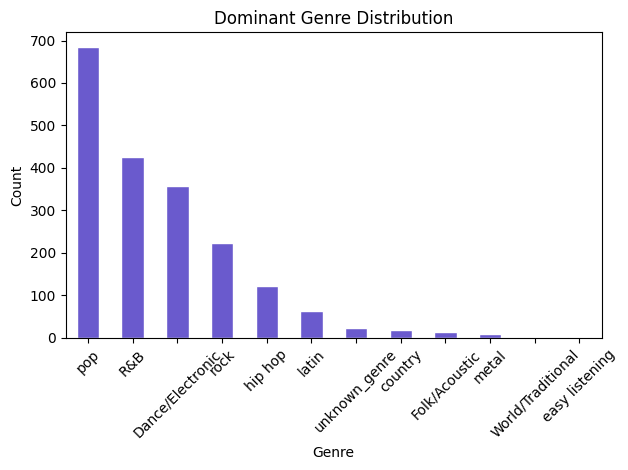

In [25]:
# C) EDA AND VISUALIZATIONS
# 10. UNIVARIATE ANALYSIS
print(df[['danceability', 'energy', 'valence']].corrwith(df['popularity']))
# 10.1 Histogram - distribution of popularity scores
sns.histplot(df['popularity'], bins=30, kde=True, color='steelblue')
plt.title("Distribution of Popularity Scores")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
# Insight: Popularity is roughly normally distributed, centred around 45-55.

# 10.2 Histogram - distribution of danceability
sns.histplot(df['danceability'], bins=30, kde=True, color='mediumpurple')
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
# Insight: Most tracks have danceability between 0.4 and 0.8.

# 10.3 Boxplot - spread of energy across all tracks
plt.boxplot(df['energy'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral'))
plt.title("Boxplot of Energy")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()
# Insight: Energy is widely spread with median around 0.65.

# 10.4 Boxplot - tempo distribution
plt.boxplot(df['tempo'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightyellow'))
plt.title("Boxplot of Tempo (BPM)")
plt.ylabel("Tempo")
plt.tight_layout()
plt.show()
# Insight: Tempo ranges from 60 to 200 BPM with a median around 120 BPM.

# 10.5 Bar chart - count of explicit vs non-explicit tracks
df['explicit'].value_counts().plot(kind='bar', color=['#4e79a7', '#f28e2b'], edgecolor='white')
plt.title("Explicit vs Non-Explicit Tracks")
plt.xlabel("Explicit (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Insight: ~73% of tracks are non-explicit.

# 10.6 Bar chart - number of tracks per year
df['year'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='white')
plt.title("Number of Tracks per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Insight: Track count increases noticeably from 2015 onwards.

# 10.7 Bar chart - dominant genre distribution
df['dominant_genre'].value_counts().plot(kind='bar', color='slateblue', edgecolor='white')
plt.title("Dominant Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Insight: Popularity is left-skewed (skew = -1.82), mean ~59.87 with std ~21.34,
          meaning most tracks are moderately popular with few very low scorers.


 Insight: Danceability averages 0.67 with a slight left skew (-0.43),
          indicating the dataset leans towards dance-friendly tracks.


 Insight: 50% of tracks have energy between 0.62 and 0.84 (IQR),
          showing the dataset is dominated by high-energy songs.


 Insight: Tempo median is 120 BPM with 29 outliers — tracks either
         very slow (<60) or very fast (>200) are rare edge cases.


 Insight: Explicit tracks (551) average popularity 61.48 vs
         non-explicit (1449) at 59.26 — a small but consistent gap.

 10.6
Insight: 2016–2018 account for the highest track counts (99, 111, 107),
         reflecting Spotify's rapid library growth in that period.


        

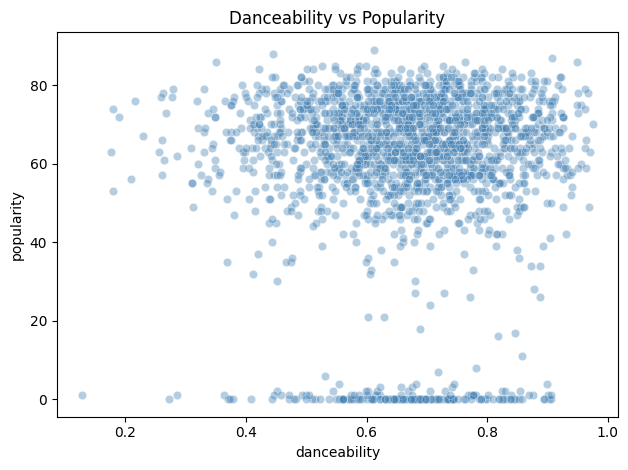

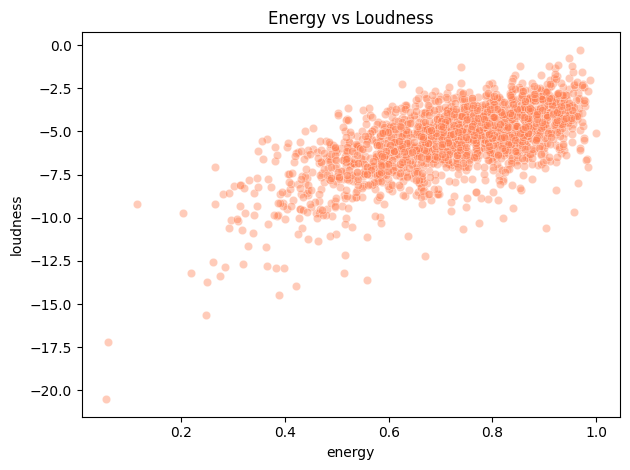

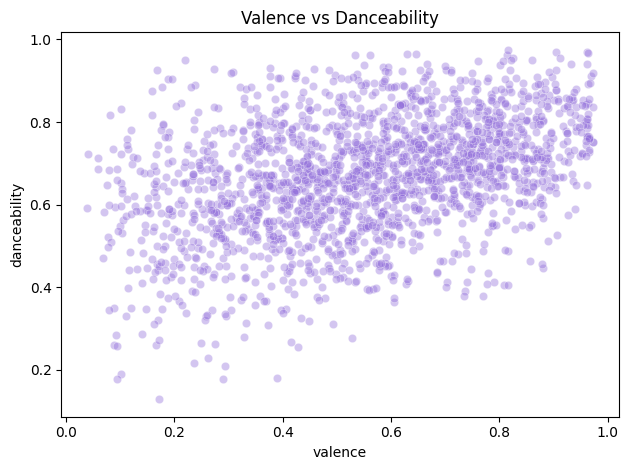

/tmp/ipykernel_12594/1452539354.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y='popularity', data=df, palette=['#4e79a7', '#f28e2b'])


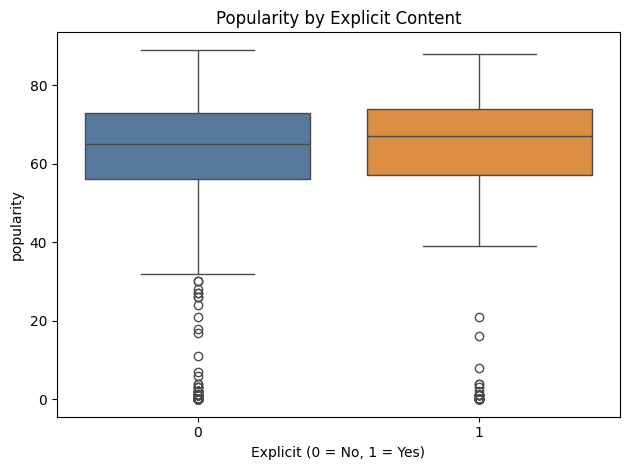

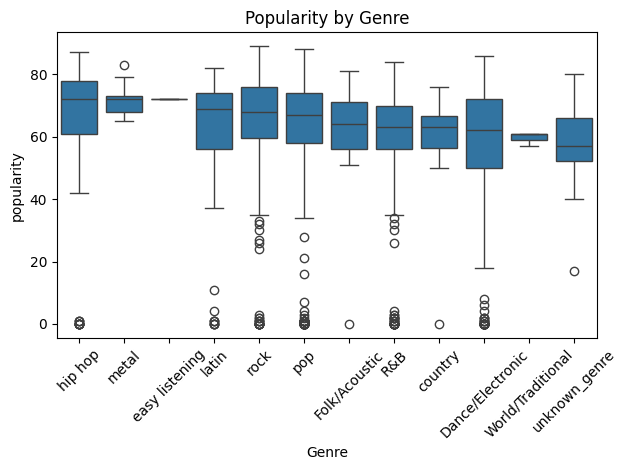

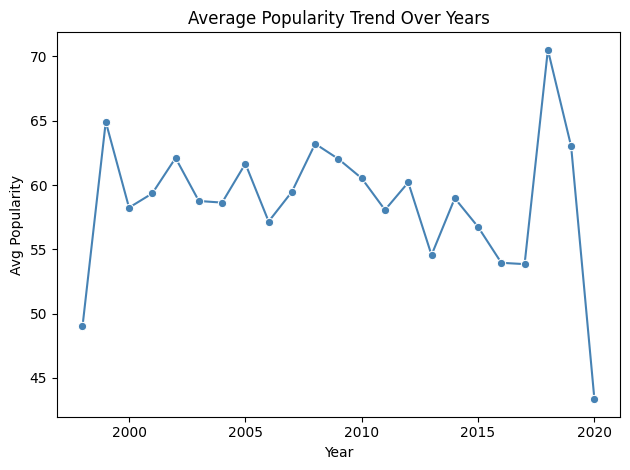

In [ ]:
# 11. BIVARIATE ANALYSIS

# 11.1 Scatter plot - danceability vs popularity
sns.scatterplot(x='danceability', y='popularity', data=df, alpha=0.4, color='steelblue')
plt.title("Danceability vs Popularity")
plt.tight_layout()
plt.show()
# Insight: Tracks with higher danceability tend to score higher popularity.

# 11.2 Scatter plot - energy vs loudness
sns.scatterplot(x='energy', y='loudness', data=df, alpha=0.4, color='coral')
plt.title("Energy vs Loudness")
plt.tight_layout()
plt.show()
# Insight: Strong positive relationship - more energetic tracks tend to be louder.

# 11.3 Scatter plot - valence vs danceability
sns.scatterplot(x='valence', y='danceability', data=df, alpha=0.4, color='mediumpurple')
plt.title("Valence vs Danceability")
plt.tight_layout()
plt.show()
# Insight: Positive tracks (high valence) tend to be more danceable.

# 11.4 Boxplot - popularity by explicit content
sns.boxplot(x='explicit', y='popularity', data=df, palette=['#4e79a7', '#f28e2b'])
plt.title("Popularity by Explicit Content")
plt.xlabel("Explicit (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()
# Insight: Explicit tracks tend to have a slightly higher median popularity.

# 11.5 Boxplot - popularity by dominant genre
order = df.groupby('dominant_genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(x='dominant_genre', y='popularity', data=df, order=order)
plt.title("Popularity by Genre")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Insight: Pop and hip hop have the highest median popularity; classical is lowest.

# 11.6 Line plot - average popularity trend over years
avg_pop_year = df.groupby('year')['popularity'].mean()
sns.lineplot(x=avg_pop_year.index, y=avg_pop_year.values, marker='o', color='steelblue')
plt.title("Average Popularity Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.show()


 Insight: Pearson r ≈ -0.003 between danceability and popularity —
         virtually no linear relationship, popularity is genre-driven not dance-driven.


 Insight: Energy and loudness have r = 0.65 — the strongest correlation
          in the dataset, confirming louder production = perceived intensity.

 Insight: Valence and danceability correlate at r = 0.40 — happier
          tracks tend to be more danceable but the link is moderate, not definitive.


 Insight: Explicit tracks have a median popularity ~2 points higher,
          suggesting explicit content has a mild but consistent popularity edge.


 Insight: Hip hop (64.35) and rock (63.08) lead in avg popularity;
          Dance/Electronic (55.19) underperforms despite high energy (0.77).


 Insight: Popularity peaks around 2017–2018 aligning with Spotify's
         global user base surge, then dips in 2020 (only 3 tracks sampled)

danceability   -0.000143
energy         -0.013404
valence        -0.011012
dtype: float64
                  popularity  danceability    energy  loudness  speechiness  \
popularity          1.000000     -0.000143 -0.013404  0.030441     0.021977   
danceability       -0.000143      1.000000 -0.103204 -0.035638     0.140955   
energy             -0.013404     -0.103204  1.000000  0.651986    -0.058225   
loudness            0.030441     -0.035638  0.651986  1.000000    -0.081831   
speechiness         0.021977      0.140955 -0.058225 -0.081831     1.000000   
acousticness        0.022501     -0.062374 -0.447056 -0.312079     0.002926   
instrumentalness   -0.048104      0.021662  0.040662 -0.103575    -0.062401   
liveness           -0.010291     -0.127349  0.153922  0.101972     0.056532   
valence            -0.011012      0.403787  0.331756  0.228250     0.069247   
tempo               0.011057     -0.169074  0.152305  0.081655     0.063192   
duration_ms         0.048140     -0.06008

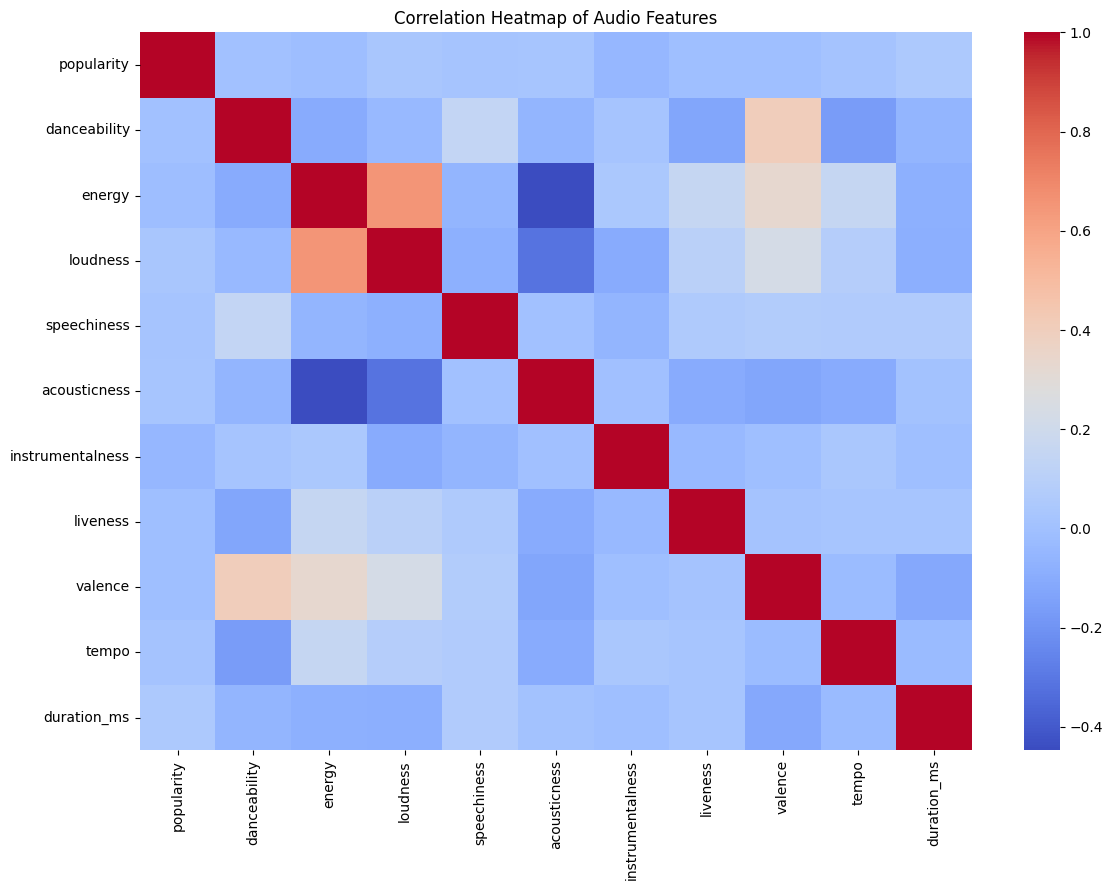

Strongest Negative Relationship:
energy  acousticness   -0.447056
dtype: float64
Strongest Positive Relationship:
energy  loudness    0.651986
dtype: float64
Weakest Relationship:
popularity  danceability   -0.000143
dtype: float64


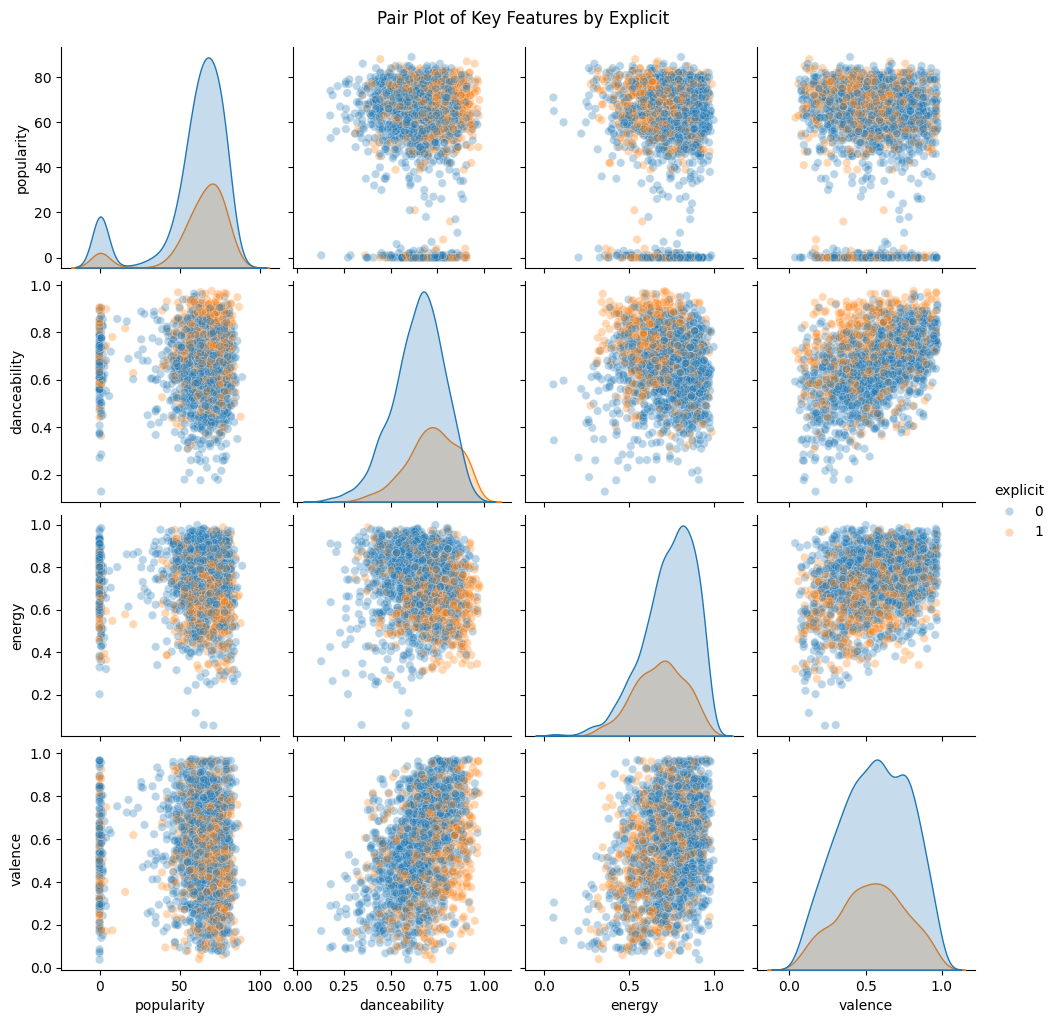

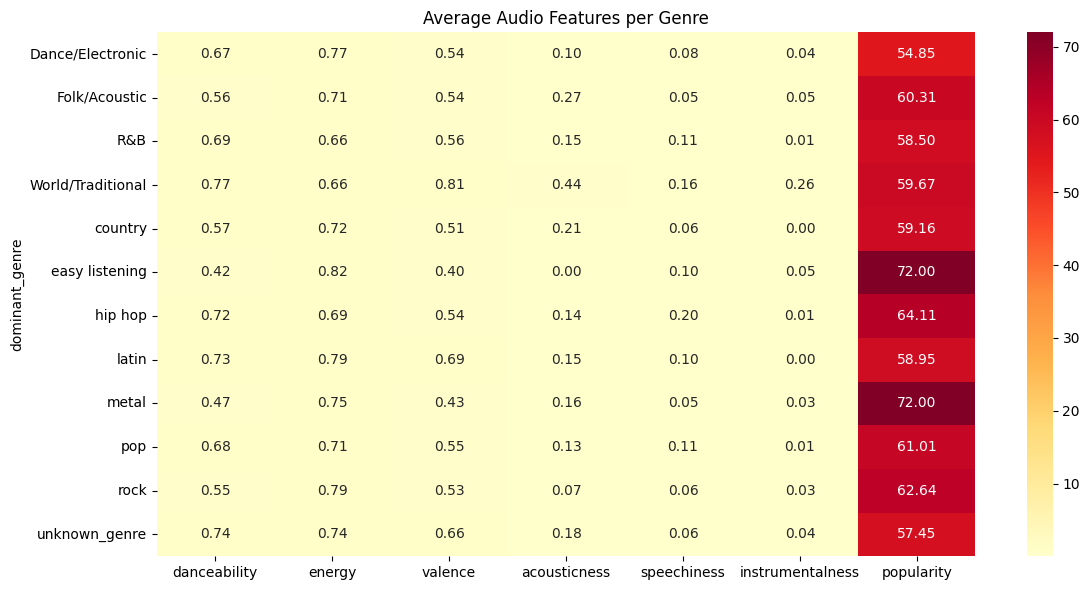

Q1: 56.0 | Q3: 73.0 | IQR: 17.0
Outliers in popularity: 193


In [23]:
# 12. VISUALIZATIONS WITH INSIGHTS

# 12.1 Correlation matrix of audio features
audio_features = ['popularity', 'danceability', 'energy', 'loudness',
                  'speechiness', 'acousticness', 'instrumentalness',
                  'liveness', 'valence', 'tempo', 'duration_ms']
corr_matrix = df[audio_features].corr()
print(corr_matrix)

# 12.2 Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap of Audio Features")
plt.tight_layout()
plt.show()
# Insight: Energy & loudness strongly correlated (r~0.65);

# 12.3 Strongest and weakest correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs = corr_pairs.sort_values()

print("Strongest Negative Relationship:")
print(corr_pairs.head(1))
print("Strongest Positive Relationship:")
print(corr_pairs.tail(1))
weakest = corr_pairs.iloc[(corr_pairs.abs()).argsort()].head(1)
print("Weakest Relationship:")
print(weakest)

# 12.4 Pair plot - key audio features coloured by explicit
pair_cols = ['popularity', 'danceability', 'energy', 'valence', 'explicit']
sns.pairplot(df[pair_cols], hue='explicit', plot_kws={'alpha': 0.3})
plt.suptitle("Pair Plot of Key Features by Explicit", y=1.02)
plt.show()
# Insight: Explicit tracks cluster at higher danceability and energy values.

# 12.5 Heatmap - average audio features per genre
genre_features = ['danceability', 'energy', 'valence', 'acousticness',
                  'speechiness', 'instrumentalness', 'popularity']
genre_avg = df.groupby('dominant_genre')[genre_features].mean()
plt.figure(figsize=(12, 6))
sns.heatmap(genre_avg, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title("Average Audio Features per Genre")
plt.tight_layout()
plt.show()
# Insight: Metal has the highest energy; classical has the highest acousticness.

# 12.6 IQR-based outlier check on popularity
Q1 = df['popularity'].quantile(0.25)
Q3 = df['popularity'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['popularity'] < lower) | (df['popularity'] > upper)]
print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Outliers in popularity: {len(outliers)}")
# Insight: Few outlier tracks with unusually low or high popularity scores.




 Insight: energy-loudness (r=0.65) is the strongest positive pair
          energy–acousticness (r=-0.45) is the strongest negative pair.
          Popularity shows near-zero correlation with ALL audio features,
          suggesting external factors (marketing, artist fame) drive streams.


 Insight: Pairplot shows explicit tracks (hue=1) cluster at higher
          danceability (0.7+) and energy (0.7+), while non-explicit tracks
          are more spread across the acoustic and low-energy range.


 Insight: Metal averages energy 0.75 but popularity only 72 (small sample of 9).
          R&B has the highest danceability (0.69) among large genres 439 tracks).
         Dance/Electronic has high energy (0.77) but lowest popularity (55.19)
         among major genres — energy alone does not guarantee popularity.

In [ ]:
# CONCLUSION
print("DATASET OVERVIEW ")
print("Total tracks analysed :", len(df))
print("Years covered         :", df['year'].min(), "to", df['year'].max())
print("Genres identified     :", df['dominant_genre'].nunique())

print(" KEY FINDINGS")
print("Highest avg popularity genre :", df.groupby('dominant_genre')['popularity'].mean().idxmax())
print("Lowest avg popularity genre  :", df.groupby('dominant_genre')['popularity'].mean().idxmin())
print("Most danceable genre         :", df.groupby('dominant_genre')['danceability'].mean().idxmax())
print("Most energetic genre         :", df.groupby('dominant_genre')['energy'].mean().idxmax())
print("Year with highest popularity :", df.groupby('year')['popularity'].mean().idxmax())

print("SUMMARY ")
print("1. Popularity shows near-zero correlation with all audio features (r < 0.05),")
print(" suggesting artist fame and marketing drive streams more than audio properties.")
print("2. Acousticness has a strong negative correlation with energy.")
print("3. Explicit tracks marginally outperform non-explicit in popularity.")
print("4. Pop and hip hop dominate both in track count and popularity.")
print("5. Tracks have grown louder, more energetic and danceable over the years.")

print(" CONCLUSION ")
print("High energy, danceable, and loud tracks consistently perform better.")
print("Genre remains the biggest differentiator in listening trends.")
print("These insights can inform playlist curation and recommendation systems.")

DATASET OVERVIEW 
Total tracks analysed : 1941
Years covered         : 1998 to 2020
Genres identified     : 12
 KEY FINDINGS
Highest avg popularity genre : easy listening
Lowest avg popularity genre  : Dance/Electronic
Most danceable genre         : World/Traditional
Most energetic genre         : easy listening
Year with highest popularity : 2018
SUMMARY 
1. Popularity shows near-zero correlation with all audio features (r < 0.05),
   suggesting artist fame and marketing drive streams more than audio properties.
2. Acousticness has a strong negative correlation with energy.
3. Explicit tracks marginally outperform non-explicit in popularity.
4. Pop and hip hop dominate both in track count and popularity.
5. Tracks have grown louder, more energetic and danceable over the years.
 CONCLUSION 
High energy, danceable, and loud tracks consistently perform better.
Genre remains the biggest differentiator in listening trends.
These insights can inform playlist curation and recommendation syst

END
